# American Coffee Survey Analysis

#### Background
In this project, we'll be analyzing the results on a survey conducted by James Hoffmann, a leading coffee influencer and the winner of the 2007 Barista Champtionship. Hoffman and his team began his survey in late 2023, surveying around 4,000 people in the US. Participants were asked about their various coffee preferences, habits, and demographics.

The crux of the survey surrounded a sample of four different coffees that participants were provided to taste test:

Coffee A - Light Roast, Washed
Coffee B - Medium Roast
Coffee C - Dark Roast
Coffee D - Light Roast, Natural

The difference between Coffee A and D comes down the processing method. Coffee D's natural process results in fermentation, leading to a more distinct, fruity taste profile.

Its important to note that participation was voluntary and the survey was announced on Hoffmann's social channels. As a result, the data skews towards an audience likely already familiar or experienced with coffee.

#### Goals and Methodology
As a coffee enthusiast myself, I was interested in exploring this dataset to see if there were any patterns in demographics or coffee habits that could be linked to a specific preference in coffee type. 

In a real world context, I could see this data being used to inform a specialty coffee shop or roastery as to which coffees to stock, as well as what types of consumer profiles to market towards.

To achieve these results, we'll deploy a few forms of classification algorithms on the data. We'll also utilize clustering methods to see if we can segment the customer base.

## 1) Setup and Data Importing

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("../Datasets/Coffee Results.csv")

In [71]:
df.head()

,Submission ID,Age,Cups per Day,Drink Location,Home Brew Method,Home Brew Method Other,Outdoor Coffee,Outdoor Coffee Other,Preferred Coffee Drink,Preferred Coffee Drink Other,...,Max Coffee Cup Spend Willingness,Value at Café,Coffee Equipment Spend,Coffee Equipment Value,Gender,Education Level,Ethnicity,Employment Status,Number of Children,Political Affiliation
0,gMR29l,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,Regular drip coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BkPN0e,25-34 years old,NaN,NaN,Pod/capsule machine (e.g. Keurig/Nespresso),NaN,NaN,NaN,Iced coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,W5G8jj,25-34 years old,NaN,NaN,Bean-to-cup machine,NaN,NaN,NaN,Regular drip coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4xWgGr,35-44 years old,NaN,NaN,Coffee brewing machine (e.g. Mr. Coffee),NaN,NaN,NaN,Iced coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,QD27Q8,25-34 years old,NaN,NaN,Pour over,NaN,NaN,NaN,Latte,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4042 entries, 0 to 4041
Data columns (total 57 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Submission ID                      4042 non-null   object 
 1   Age                                4011 non-null   object 
 2   Cups per Day                       3949 non-null   object 
 3   Drink Location                     3972 non-null   object 
 4   Home Brew Method                   3657 non-null   object 
 5   Home Brew Method Other             678 non-null    object 
 6   Outdoor Coffee                     710 non-null    object 
 7   Outdoor Coffee Other               31 non-null     object 
 8   Preferred Coffee Drink             3980 non-null   object 
 9   Preferred Coffee Drink Other       115 non-null    object 
 10  Coffee Additions                   3959 non-null   object 
 11  Coffee Additions Other             48 non-null     objec

In [73]:
df.describe()

,Flavoring Type,Flavoring Type Other,Reported Coffee Expertise,Coffee A - Bitterness,Coffee A - Acidity,Coffee A - Personal Preference,Coffee B - Bitterness,Coffee B - Acidity,Coffee B - Personal Preference,Coffee C - Bitterness,Coffee C - Acidity,Coffee C - Personal Preference,Coffee D - Bitterness,Coffee D - Acidity,Coffee D - Personal Preference
count,0.0,0.0,3938.000000,3798.000000,3779.000000,3789.000000,3780.000000,3767.000000,3773.000000,3764.000000,3751.000000,3766.000000,3767.000000,3765.000000,3764.000000
mean,NaN,NaN,5.693499,2.141127,3.634824,3.310900,3.013228,2.223786,3.068646,3.071998,2.366836,3.064790,2.162729,3.858167,3.375930
std,NaN,NaN,1.948867,0.947163,0.982113,1.185953,0.992875,0.865389,1.113546,0.999267,0.921048,1.128431,1.081546,1.007973,1.452504
min,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,NaN,NaN,5.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000
50%,NaN,NaN,6.000000,2.000000,4.000000,3.000000,3.000000,2.000000,3.000000,3.000000,2.000000,3.000000,2.000000,4.000000,4.000000
75%,NaN,NaN,7.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,3.000000,5.000000,5.000000
max,NaN,NaN,10.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [74]:
# Drop unnecesary Submission Identifier

df = df.drop('Submission ID', axis=1)

In [75]:
# Check overall percentage of missing values

total_miss = df.isna().sum().sum()

print(total_miss/df.size * 100)

26.25777550010603


In [76]:
# Check for rows with a large amount of missing values

miss_rows = np.round(df.isna().sum(axis=1)/df.shape[1]*100, 2)

miss_rows.sort_values(ascending=False)

11      100.00
27      100.00
7       100.00
9       100.00
12      100.00
         ...  
1956     10.71
2379     10.71
3867     10.71
3674     10.71
657       8.93
Length: 4042, dtype: float64

There's a very large share of missing data in the survey results, over a fourth of the total data set. Given the variety of granular questions and apparent ability to skip over certain questions, it's not particularly surprising.
Let's spend a bit of time clearing rows and columns with a significant lack of data, and fill in empty spaces with reasonable assumptions.

## 2) Cleaning Missing Values

Text(0.5, 1.0, 'Distribution of Missing % in Rows')

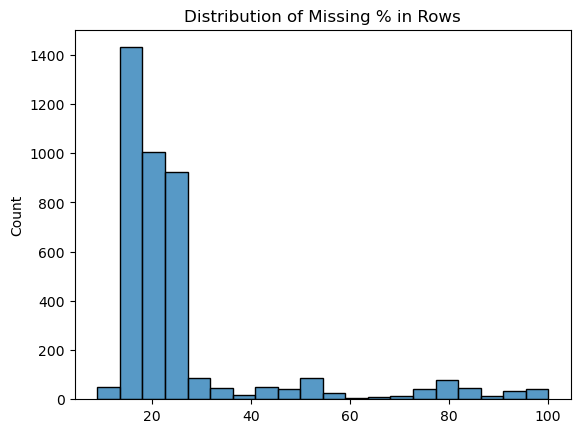

In [77]:
# Explore the distribution of rows with missing values.

sns.histplot(miss_rows, bins=20) 
plt.title('Distribution of Missing % in Rows')



In [78]:
# Check cut-off points for completion

print('Percent of Rows with at least 40% completion:')
print((miss_rows[miss_rows < 40].shape[0] / miss_rows.shape[0]) * 100) 

print('Percent of Rows with at least 30% completion:')
print((miss_rows[miss_rows < 30].shape[0] / miss_rows.shape[0]) * 100) 

print('Percent of Rows with at least 20% completion:')
print((miss_rows[miss_rows < 20].shape[0] / miss_rows.shape[0]) * 100) 

Percent of Rows with at least 40% completion:
88.02572983671449
Percent of Rows with at least 30% completion:
85.65066798614546
Percent of Rows with at least 20% completion:
54.79960415635824


We'll chose 30% as our threshold for missing data among rows - balances out the preservation of overall entries to about 85%.

In [79]:
df = df.dropna(thresh=int(0.30 * len(df.columns)))

Now we'll check for columns than can be dropped based on incompleteness.

In [80]:
# Check for missing values across columns as a percentage value

miss_cols = np.round(df.isna().sum()/df.shape[0]*100, 2)
miss_cols.sort_values(ascending=False)

Flavoring Type                       100.00
Flavoring Type Other                 100.00
Outdoor Coffee Other                  99.26
Coffee Additions Other                98.81
Preferred Coffee Drink Other          97.04
Coffee Drinking Reason Other          95.59
Sweetener Type                        87.20
Home Brew Method Other                82.96
Outdoor Coffee                        82.14
Number of Children                    77.41
Dairy Type                            57.23
Coffee C - Notes                      37.15
Coffee B - Notes                      35.25
Coffee A - Notes                      31.98
Coffee D - Notes                      31.72
Political Affiliation                 13.22
Ethnicity                              9.82
Employment Status                      9.79
Education Level                        9.29
Home Brew Method                       8.15
Coffee Equipment Value                 7.81
Value at Café                          7.65
Coffee Equipment Spend          

There's a few columns with a large chunk of missing values worth exploring before dropping.

Let's explore the columns with missing values above 50%. Everything above this threshold appears to be tied to explainable behavioral or preferencial tendencies.


In [81]:
# Several of the offending columns are related to additives. Check what percent of those surveyed add to their coffee.

additive_count = df['Coffee Additions'].str.split(r', (?=[A-Z])').explode().value_counts(dropna=False) # Expand out the freetext column related to additives in coffee.

np.round(additive_count/df.shape[0] * 100) 

Coffee Additions
No - just black                               66.0
Milk, dairy alternative, or coffee creamer    43.0
Sugar or sweetener                            13.0
Flavor syrup                                   6.0
Other                                          1.0
NaN                                            0.0
Name: count, dtype: float64

Most respondents seem to be drinking straight or adding only milk. Let's drop all columns related to the other options. We'll also drop other columns with very few responses.

In [82]:
# Drop near empty columns

drop_list = ['Flavoring Type',
'Flavoring Type Other',
'Outdoor Coffee Other',
'Coffee Additions Other',
'Preferred Coffee Drink Other',
'Coffee Drinking Reason Other',
'Sweetener Type',
'Home Brew Method Other',
'Outdoor Coffee']

df = df.drop(drop_list, axis=1)

There's a few other columns that we can assume the value of and fill with a placeholder.

Missing values for number of children will be filled with zero, since that doesn't seem to have been an option for respondents.
We'll also fill missing values in the dairy column with 'None' values.
Lastly, we'll fill in missing values from Reported Coffee Experience with a zero value to prevent future errors.

In [83]:
# Fill certain columns with reasonable estimates
df['Number of Children'] = df['Number of Children'].fillna('0')
df['Dairy Type'] = df['Dairy Type'].fillna('None')
df['Reported Coffee Expertise'] = df['Reported Coffee Expertise'].fillna(0)

In [84]:
# Drop Freeform Text Columns
textresp_df = ['Coffee A - Notes', 'Coffee B - Notes', 'Coffee C - Notes', 'Coffee D - Notes']
df = df.drop(textresp_df, axis=1)

In [85]:
# Rechecking overall missing values across columns

total_miss = df.isna().sum().sum()

print(total_miss/df.size * 100)

miss_cols = np.round(df.isna().sum()/df.shape[0]*100, 2)

miss_cols.sort_values(ascending=False)

3.223292630545499


Political Affiliation                13.22
Ethnicity                             9.82
Employment Status                     9.79
Education Level                       9.29
Home Brew Method                      8.15
Coffee Equipment Value                7.81
Value at Café                         7.65
Coffee Equipment Spend                7.49
Max Coffee Cup Spend Willingness      7.39
Monthly Coffee Spend                  7.36
Gender                                7.04
Work Setup                            7.02
Max Coffee Cup Purchase               6.94
Coffee Sourcing Knowledge             6.09
Coffee Taste Enjoyment                5.99
Coffee Drinking Reason                5.86
Coffee C - Acidity                    1.06
Favorite Coffee Between A and D       0.95
Favorite Coffee Overall               0.77
Preferred Coffee Strength             0.77
Coffee D - Personal Preference        0.74
Coffee C - Bitterness                 0.71
Preferred Caffeine                    0.69
Coffee D - 

We now have less than 5% of the data missing with our adjustments. Because we'll be performing clustering down the line, we'll have to fill in the remaining missing values.
For the sake of the analysis, we'll fill those values in with the mode. With so few values to fill, this shouldn't heavily skew the results.

In [86]:
# Fill remaining missing data with mode and reset the index of the dataframe
df = df.fillna(df.mode().iloc[0]).reset_index(drop=True)

### 2) EDA

#### Summary Overview of Responses

To start off our exploratory analysis, we'll take a broad look at the survey population and it's most distinct characteristics.

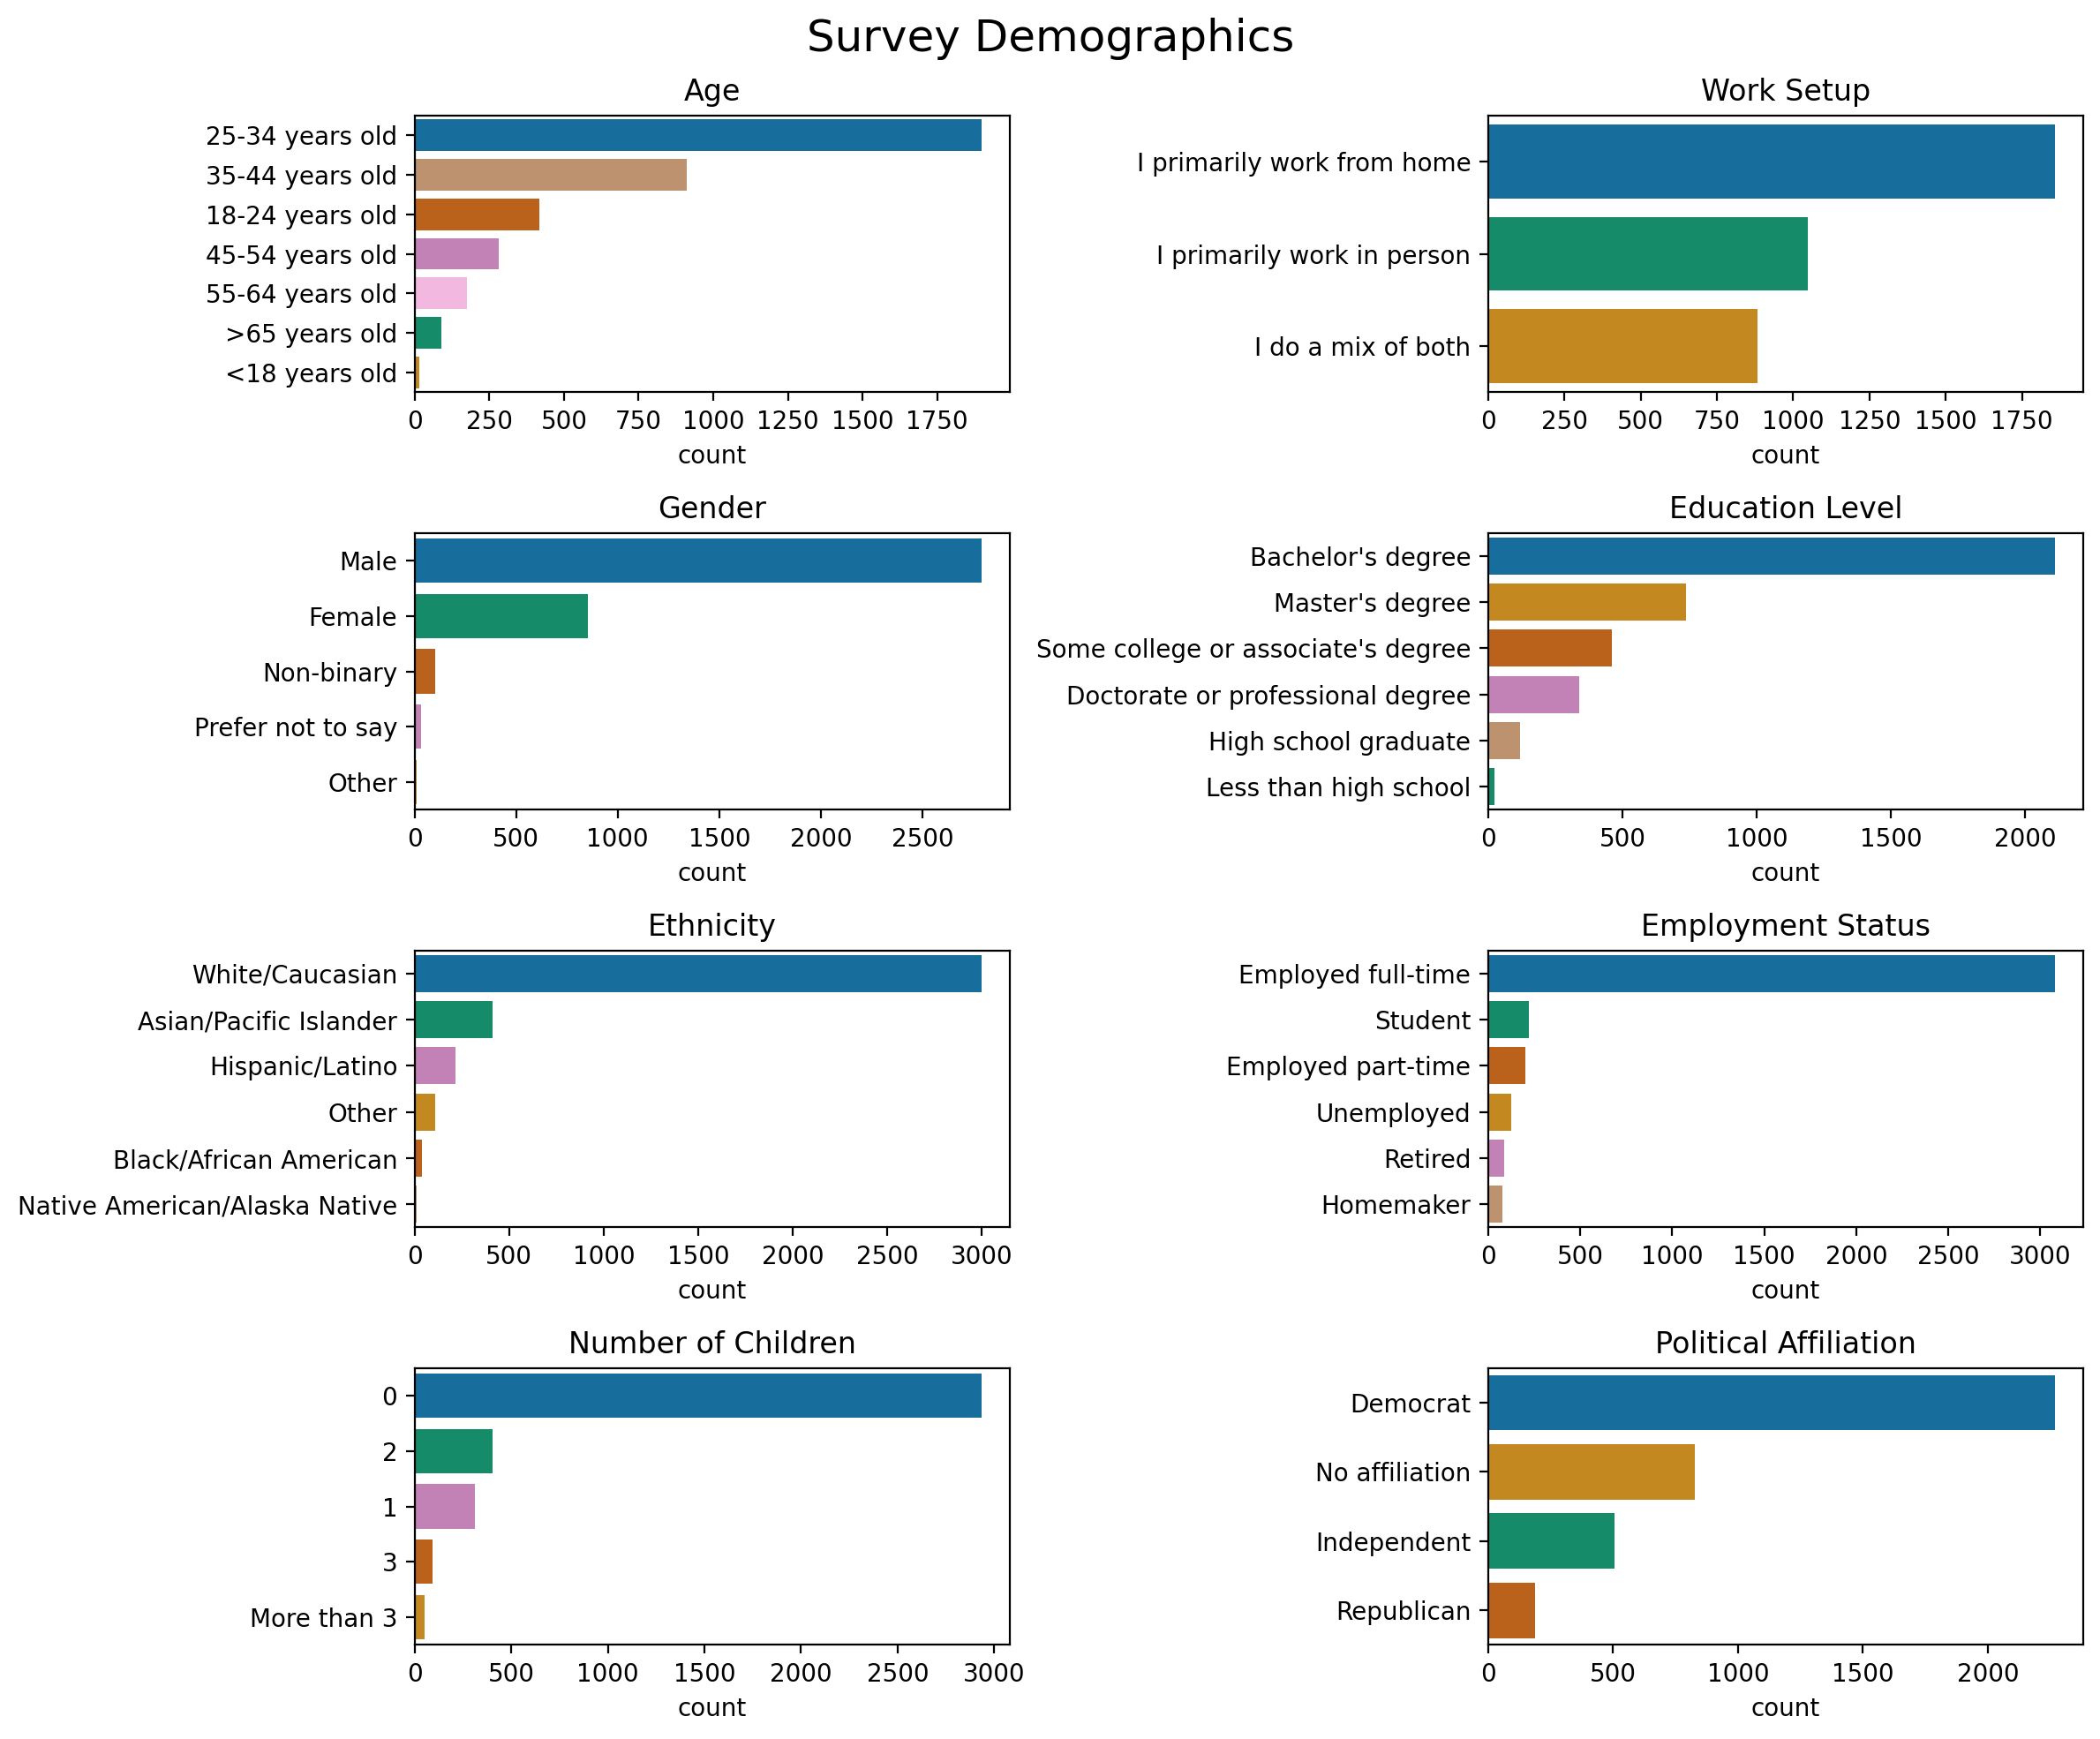

In [87]:
# Visualize key demographics

col_list = ['Age',
             'Work Setup',
             'Gender',
             'Education Level',
             'Ethnicity',
             'Employment Status',
             'Number of Children',
             'Political Affiliation']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12,10), dpi=200)

for i in range(0,8):
    col = col_list[i]

    sns.countplot(df, y=col, hue=col, legend=False, 
                  order=df[col].value_counts().index,
                  ax=axes.flat[i], palette='colorblind')

    axes.flat[i].set_ylabel(None)
    axes.flat[i].set_title(col)
    axes.flat[i].tick_params()

plt.suptitle('Survey Demographics', fontsize=18)
plt.tight_layout()


Survey demographics indicate most respondents are young, educated, full-time workers. They also skew heavily male, caucasian, and left-leaning overall.

A large segment of the audience appears to be working from home, or in hybrid setups. Can be inferred that most of the respondents are white collar workers, likely middle- to upper-class earners.

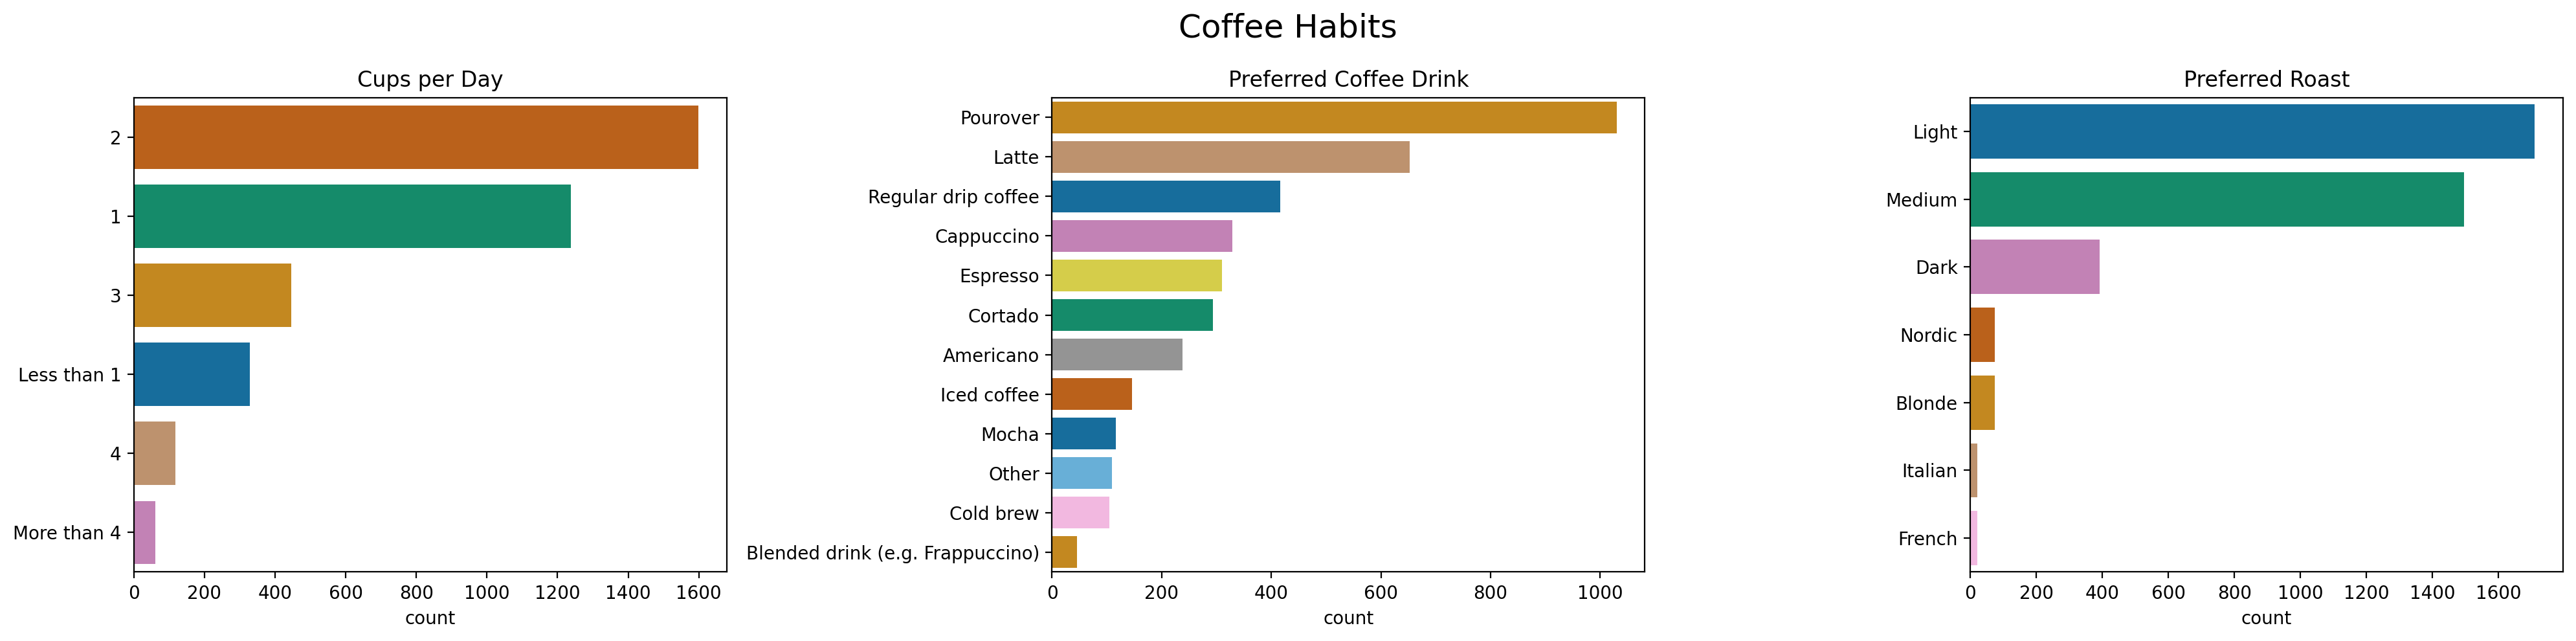

In [88]:
# Coffee Habits

col_list = ['Cups per Day',
            'Preferred Coffee Drink',
            'Preferred Roast']

# Define function to expand out multiselect items
def mult_explode(df, column):
    col = df[column].str.split(r', (?=[A-Z])')
    col = col.explode()
    return col

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20,5), dpi=200)

for i in range(0,3):
    col = col_list[i]

    sns.countplot(df,y=col, hue=col, legend=False, 
                  order=df[col].value_counts().index,
                  ax=axes.flat[i], palette='colorblind')

    axes.flat[i].set_ylabel(None)
    axes.flat[i].set_title(col)

plt.suptitle('Coffee Habits', fontsize=18)
plt.tight_layout()


Those surveyed drank a relatively low amount of coffee daily, with only one to two cups winning the majority vote.

However, this doesn't necessarily indicate the group is impassionate about coffee. Most respondents prefer a pourover and light-leaning roast options. These trends indicate we're most of the entries came from experienced coffee drinkers, it's just that they tend to not drink too many cups overall.

It's likely that enthusiast coffee drinkers are largely drinking for taste and experience purposes, rather than for the caffeine bump from several cups over the course of a day.


#### Coffee Rankings Explored

In [89]:
# Stand up a set of lists and dicts to create consistent labels and colors across the analysis
coff_color = {'Coffee A':'tomato', 'Coffee B':'mediumorchid', 'Coffee C':'forestgreen', 'Coffee D':'skyblue'}
coff_title = ['Coffee A-Light Wash', 'Coffee B-Medium', 'Coffee C-Dark', 'Coffee D-Light Nat']

coff_order = list(coff_color.keys())

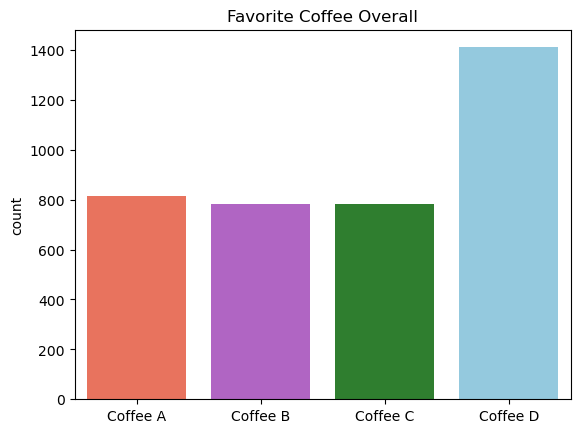

In [90]:
# Visualize overall coffee rankings by count

sns.countplot(data=df, x='Favorite Coffee Overall', 
              order=coff_order, 
              hue='Favorite Coffee Overall',
              palette=coff_color,
              legend=False)

plt.title('Favorite Coffee Overall')
plt.xlabel(None);

Coffee D wins with a large share of the vote! From the survey background info, we know that this is the fermented, light roast option. From a pure popularity vote, a speciality coffee shop should consider stocking more complex, light roast profile coffees.

Interestingly, there's a nearly split vote across the other three coffee types. 

Medium and Dark roast coffees (B and C, respectively) tend to have similar roast profiles, so the split vote amongst the two is unsurprising.

Coffee A and D were both light roasted, but the latter was fermented. This process gives coffees a more fruity, boozy taste. Natural process light roast coffees like A tend to have a more pronounced citrus note.

It's likely that Coffee D's popularity ultimately pulled away from votes for Coffee A. There's two questions in the survey that can help us explore this further.

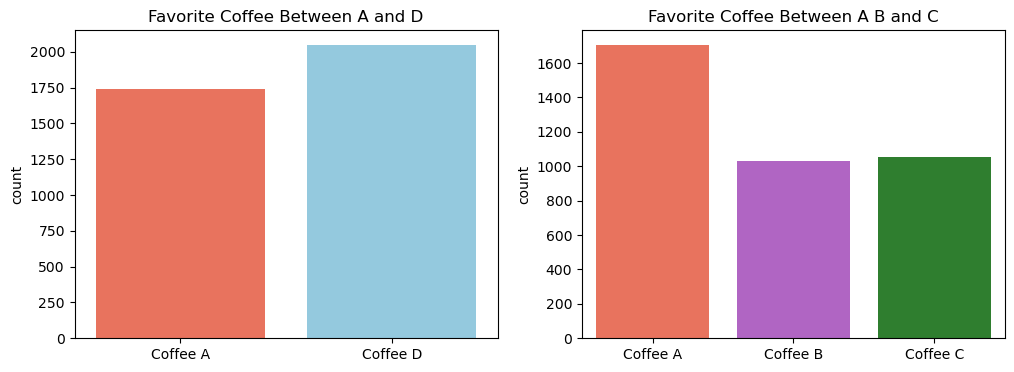

In [91]:
# Plot out the other comparison ranking questions

fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(12,4), sharey=False)

# Plot comparing A and D
sns.countplot(data=df, x='Favorite Coffee Between A and D',
              ax = axes[0], 
              order =['Coffee A', 'Coffee D'],
              hue = 'Favorite Coffee Between A and D',
              palette = coff_color,
              legend = False)

axes[0].set_title('Favorite Coffee Between A and D')
axes[0].set_xlabel(None)

# Plot comparing A B and C
sns.countplot(data=df, x='Favorite Coffee Between A B and C',
              ax = axes[1], 
              hue = 'Favorite Coffee Between A B and C',
              order = ['Coffee A', 'Coffee B', 'Coffee C'],
              palette = coff_color,
              legend=False)

axes[1].set_title('Favorite Coffee Between A B and C')
axes[1].set_xlabel(None);


In the overall match up, Coffee D leads all other coffees by almost 600 votes. Yet in a direct comparision with Coffee A, the other light roast coffee, it's only favored by by about 250 votes.

When Coffee D is introduced into the mixed, it siphons off votes across all the other three coffees compared to when they're pitted together. The coffee appears to have some desirable qualities that can sway people with existing preferences.

From a specialty shop perspective, providing samples akin to Coffee D to customers that tend to order medium or darker roast has the potential to diversify sales among an existing base.

#### Coffee Preferences across Survey Segments

Let's see how coffee type preferences breakout across two of the demographics that had notable differences in the survey makeup: gender and age.

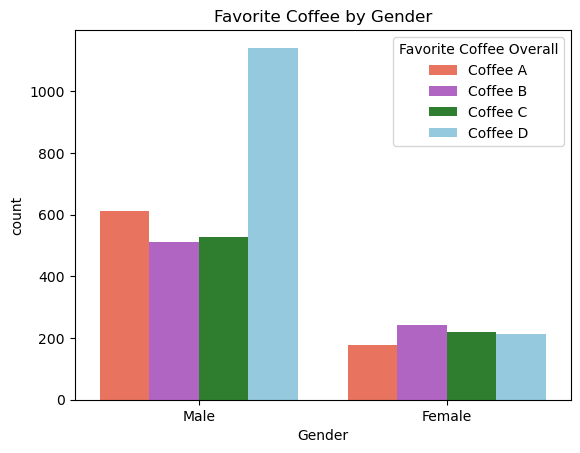

In [92]:
plot_order=df['Gender'].value_counts().head(2).index

sns.countplot(data=df, x='Gender', hue='Favorite Coffee Overall', 
              order=plot_order,
              hue_order = coff_order,
              palette=coff_color)

plt.title('Favorite Coffee by Gender');

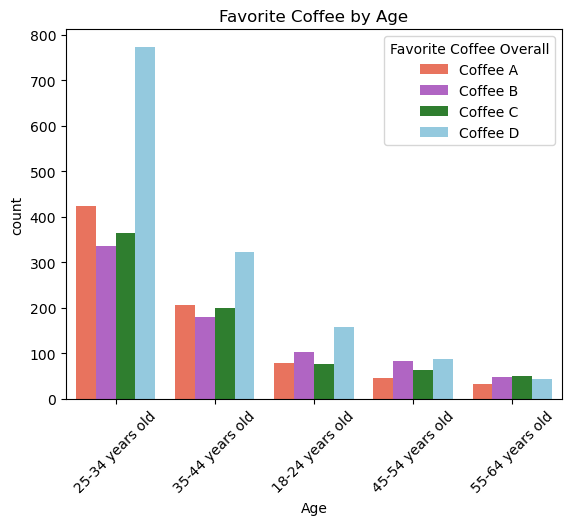

In [93]:
plot_order = df['Age'].value_counts().head(5).index

sns.countplot(data=df, x='Age', 
              hue='Favorite Coffee Overall', 
              order=plot_order,
              hue_order = coff_order,
              palette=coff_color)

plt.title('Favorite Coffee by Age')
plt.xticks(rotation=45);

Younger demographics lean towards favoring coffees on the lighter end of the spectrum, while coffee drinkers aged 45-and-up convey even preferences across types.

The more interesting developments surface when looking at gender. Men are overwhelming driving Coffee D's lead. Meanwhile women rank the coffees more closely, showing far more favor towards darker coffees than men.


Now let's see how coffee habits line up with coffee ranking results.

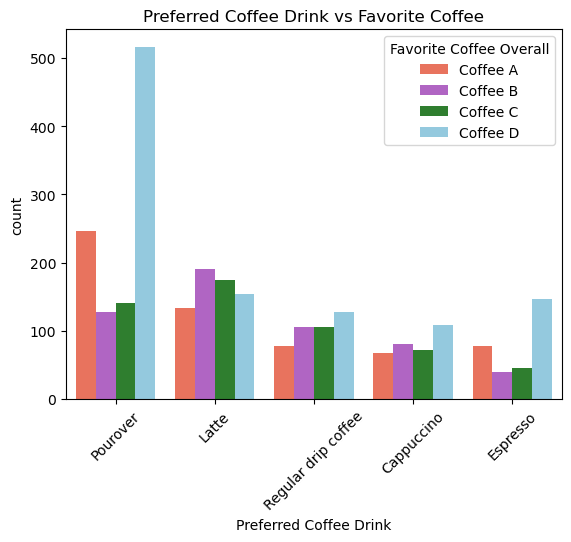

In [94]:
# Plot Preferred Coffee Drink Type against Ranking Results

plot_order = df['Preferred Coffee Drink'].value_counts().head(5).index

sns.countplot(data=df, x='Preferred Coffee Drink', 
              hue='Favorite Coffee Overall',
              hue_order = coff_order,
              order=plot_order,
              palette=coff_color)

plt.title('Preferred Coffee Drink vs Favorite Coffee')
plt.xticks(rotation=45);

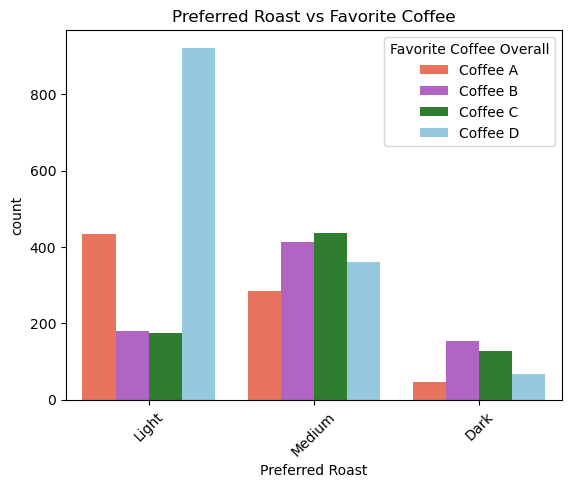

In [95]:
# Plot Preferred Roast against Ranking Results

plot_order = df['Preferred Roast'].value_counts().head(3).index

sns.countplot(data=df, x='Preferred Roast', 
              hue='Favorite Coffee Overall',
              hue_order = coff_order,
              order=plot_order,
              palette=coff_color)

plt.title('Preferred Roast vs Favorite Coffee')
plt.xticks(rotation=45);

Unsurprisingly, pourover users tend to rank the lighter coffees higher than other brew types. The manual pourover method is much better suited to pulling out the complex notes in lighter roasted coffees. Meanwhile, espresso and drip machines are struggle to do the same with light roast and produce more harshly acidic brews, so people that already drink lattes and drip coffees are more familiar with dark and medium roast coffees.

Preferred roast results indicate that people have a hard time differentiating between medium and dark roast. Those that stated they preferred those coffee types ranked both corresponding coffees quite closely in the survey results.


### Coffee Tasting Results

In the survey, respondents were asked rank the coffees on bitterness and acidity. Let's use these results to further intuit the qualities in coffee people tend to prefer.

In [96]:
# Stand up a dictionary to create consistent labels and colors across the analysis
coff_dict = {'Coffee A-Light Wash':'tomato', 'Coffee B-Medium':'mediumorchid', 'Coffee C-Dark':'forestgreen', 'Coffee D-Light Nat':'skyblue'}

In [97]:
# Define a function to quickly pull together a list of columns related to the coffees included as part of the survey.
def coffeecol_list(element):
    coffee_name = ['Coffee A', 'Coffee B', 'Coffee C', 'Coffee D']

    val_list = []

    for x in coffee_name:
        val_name = x + ' - ' + element
        val_list.append(val_name)
    return val_list 

In [98]:
# Define a bitter column list and acidity column list
bitter_list = coffeecol_list('Bitterness')
acidity_list = coffeecol_list('Acidity')

print(bitter_list)
print(acidity_list)

['Coffee A - Bitterness', 'Coffee B - Bitterness', 'Coffee C - Bitterness', 'Coffee D - Bitterness']
['Coffee A - Acidity', 'Coffee B - Acidity', 'Coffee C - Acidity', 'Coffee D - Acidity']


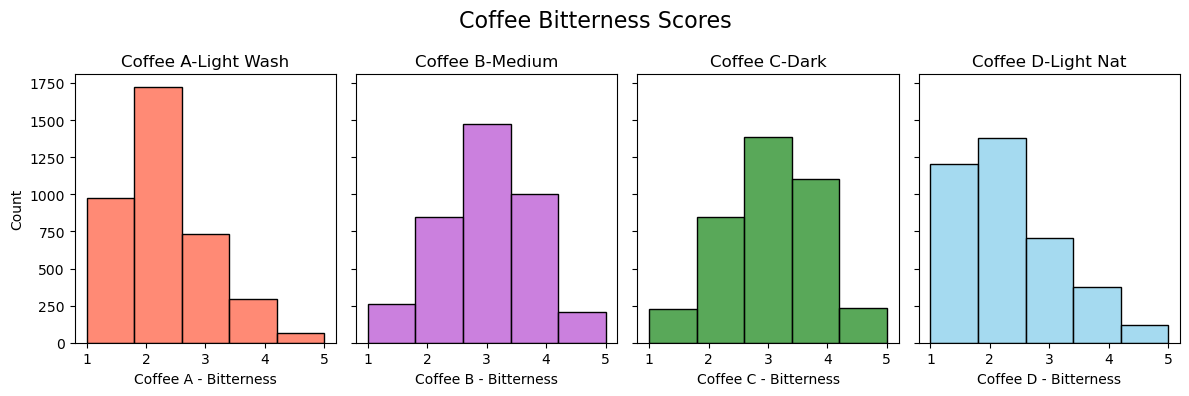

In [99]:
# Visualize scores for bitterness across coffees

fig, axes = plt.subplots(nrows=1, ncols=4,figsize=(12,4), sharey=True)

for i in range(0,4):
    sns.histplot(df[bitter_list[i]], bins=5, ax=axes[i], color=list(coff_color.values())[i])
    axes[i].set_title(coff_title[i])

plt.suptitle('Coffee Bitterness Scores', fontsize=16)

plt.tight_layout()

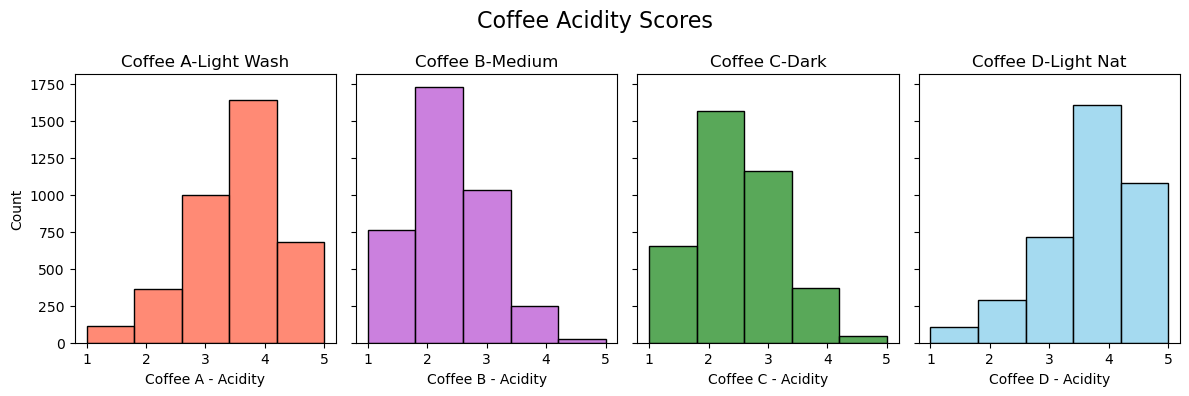

In [100]:
# Visualize scores for acidity across coffees

fig, axes = plt.subplots(nrows=1, ncols=4,figsize=(12,4), sharey=True)

for i in range(0,4):
    sns.histplot(df[acidity_list[i]], bins=5, ax=axes[i], color=list(coff_color.values())[i])
    axes[i].set_title(coff_title[i])

plt.suptitle('Coffee Acidity Scores', fontsize=16)

plt.tight_layout()

The coffees have a well defined, unimodal distribution across both bitterness and acidity.

The medium (B) and dark (C) coffees shared similar distributions, further explaining why the two coffees saw near-identical votes.

Coffee D leaned slightly more acidic and less bitter than A. 

A more acidic profile overall appears to win over the enthusiast crowd.

#### Validating Self-Reported Coffee Experience - Derived Metrics

Each participant self-reported their own coffee experience as a part of the survey. The coffee tasting results opens up an avenue to test whether those reporting higher expertise have an expectedly well-developed palette.

Given how strong the majority consensus appears for each coffee's tasting profile, let's create a derived metric called Tasting Deviation. The metric will summarize how far each respondent deviates from the popular consensus on acidity and bitterness across coffees. With this we can roughly estimate how developed each participant's palette and use that as an approximation for actual coffee expertise.


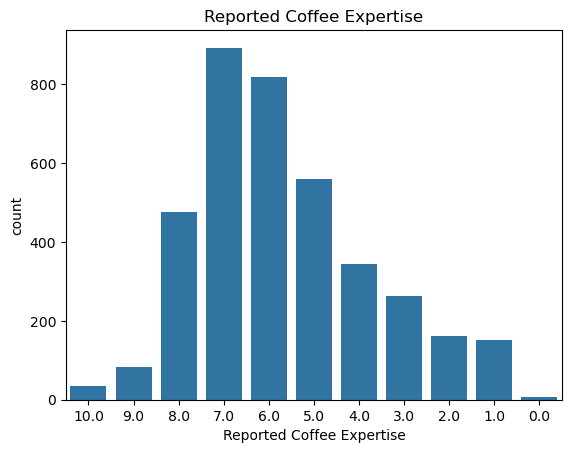

In [101]:
# Check distribution of reported coffee experience

ax = sns.countplot(df, x='Reported Coffee Expertise')
ax.set_title('Reported Coffee Expertise')
ax.invert_xaxis();

In [102]:
# Define a list of temporary column names
acid_diff_col = coffeecol_list('Acid Diff')
bitter_diff_col = coffeecol_list('Bitter Diff')

# Prepare dataframes to store information
acid_diff_df = pd.DataFrame()
bitter_diff_df = pd.DataFrame()

# Iterate through each response, calculate the tasting profile devation from the mean, then square the result.
for i in range(0,4):
    acid_col = df[acidity_list[i]] - df[acidity_list[i]].mean()
    bitter_col = df[bitter_list[i]] - df[bitter_list[i]].mean()

    acid_diff_df[acid_diff_col[i]] = np.round(acid_col, 2) ** 2
    bitter_diff_df[bitter_diff_col[i]] = np.round(bitter_col, 2) ** 2

# Combine the deviations across coffees' acidity and bitterness
combine_df = pd.concat([acid_diff_df,bitter_diff_df], axis=1) 

# Take the mean of the squared-summed values and then apply the square root
TastingDeviation = np.sqrt(combine_df.mean(axis=1)).round(2).fillna(1)


In [103]:
# Convert to a categorical score to match the other survey questions using bins
df['Tasting Score'] = pd.cut(TastingDeviation, bins=11, labels=list(np.arange(10,-1,-1)))
df['Tasting Score'] = df['Tasting Score'].astype(float)

Text(0.5, 1.0, 'Tasting Score')

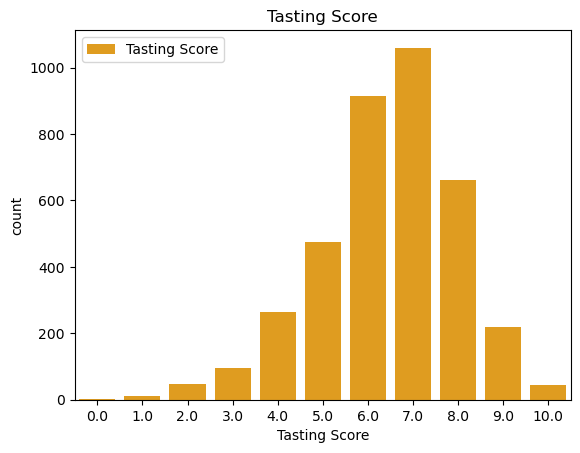

In [104]:
# Display distribution of the derived metric

sns.countplot(df, x='Tasting Score', label='Tasting Score', color='orange')
plt.title('Tasting Score')

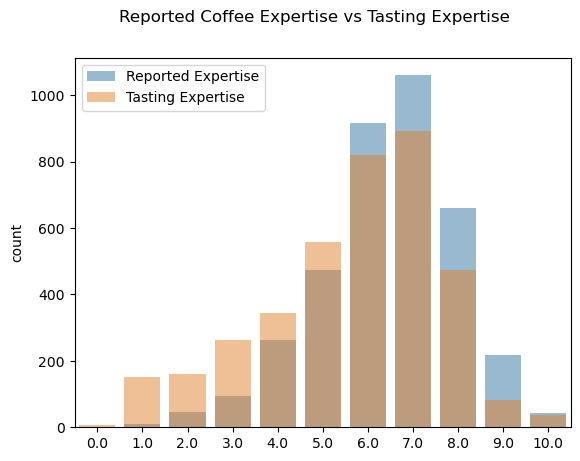

In [105]:
# Plot the two countplots overtop of each other to compare Tasting Expertise and Reported Coffee Experience

ax1 = sns.countplot(df, x='Tasting Score', alpha=0.5, label='Reported Expertise')
ax2 = sns.countplot(df, x='Reported Coffee Expertise', alpha=0.5, label='Tasting Expertise')
plt.suptitle('Reported Coffee Expertise vs Tasting Expertise')
plt.legend()
ax2.set_xlabel(None);

Tasting Deviation follows a very similar distribution with Reported Coffee Experience, revealing the survey respondents self-reported experience lines up well with their ability to judge a coffee's flavor profile.

Reported Coffee Experience has a somewhat thicker right hand tail than the derived Tasting Deviation. That differential indicates that people ranking themselves lower may be underestimating their own expertise.

The overall distribution across both metrics confirms we're dealing with a knowledgable survey group with a strong understanding of the nuances in coffee taste.

## 3) Preparing for ML

### Flattening Multi-Select Columns

Several columns have multiple answers combined into a single entry. We'll need to expand those out and give them their own dedicated columns as dummy variables.

In [106]:
# Define function to iterate through multi-select answers and return dummy variables

def multi_sel_dum(df,column_name):
    clean_col = df[column_name].str.split(r', (?=[A-Z])') # split and clean list
    clean_col = clean_col.str.join("|") # rejoin list for dummy assignment
    new_dummies = clean_col.str.get_dummies().add_prefix(column_name+"_").astype(bool) # assign dummies and add a prefix
    return new_dummies

In [107]:
# Define dictionary of columns with multi-select lists to convert to dummy variables

multi_col = {'Work Setup',
    'Coffee Drinking Reason',
    'Dairy Type',
    'Coffee Additions',
    'Home Brew Method',
    'Drink Location'}


In [108]:
# Convert multi-select columns to dummies and drop the originals

for col in multi_col:
    new_df = multi_sel_dum(df,col)
    df = pd.concat([df,new_df], axis=1)

    df = df.drop(col, axis=1)


#### Ordinal Encoding

In [109]:
# Identify columns with an existing order, create ordinal assignment

ord_dict = {'Age':['<18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', '55-64 years old', '>65 years old'],
'Cups per Day':['Less than 1', '1', '2', '3', '4', 'More than 4'],
'Preferred Coffee Strength':['Weak', 'Somewhat light', 'Medium', 'Somewhat strong', 'Very strong'],
'Preferred Caffeine':['Decaf', 'Full caffeine', 'Half caff'],
'Monthly Coffee Spend':['<$20', '$20-$40', '$40-$60', '$60-$80', '$80-$100', '>$100'],
'Max Coffee Cup Purchase':['Less than $2', '$2-$4', '$4-$6', '$6-$8', '$8-$10', '$10-$15', '$15-$20', 'More than $20'],
'Max Coffee Cup Spend Willingness':['Less than $2', '$2-$4', '$4-$6', '$6-$8', '$8-$10', '$10-$15', '$15-$20', 'More than $20'],
'Coffee Equipment Spend':['Less than $20', '$20-$50', '$50-$100', '$100-$300', '$300-$500', '$500-$1000', 'More than $1,000'],
'Number of Children':['0' ,'1', '2', '3', 'More than 3']}

In [110]:
from sklearn.preprocessing import OrdinalEncoder

In [111]:
# Assign ordinal values

for key, value in ord_dict.items():
    encoder = OrdinalEncoder(categories = [value])
    df[key] = encoder.fit_transform(df[[key]])

#### Drop Unnecessary Columns and Convert Remaining Categorical Variables

In [112]:
# Drop columns closely associated with the response variable

pref_df = coffeecol_list('Personal Preference')
compare_df = ['Favorite Coffee Between A B and C',
'Favorite Coffee Between A and D']

eval_list = pref_df + compare_df + bitter_list + acidity_list
eval_df = df[eval_list]

df = df.drop(eval_list, axis=1) # Drop these columns from the overall df

In [113]:
# Lastly, we'll convert the remaining categorical variables into dummy variables

X = df.drop('Favorite Coffee Overall', axis=1)
X = pd.get_dummies(data=X, drop_first=True)

y = df['Favorite Coffee Overall']

## 4) Classification 

In [114]:
# Before starting, let's define a one-step evaluation formula for classification:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

def class_eval(y_test, y_pred, labels):
    print(classification_report(y_test,y_pred))
    cm = confusion_matrix(y_test,y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()
    plt.title('Confusion Matrix')

In [115]:
from sklearn.model_selection import train_test_split

In [116]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=90)

In [117]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

#### Logistic Regression

In [118]:
from sklearn.linear_model import LogisticRegression

In [119]:
# Define pipeline with operations

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])

In [120]:
# Outline hyperparameters to test in the model

param_grid = {'classifier__penalty': ['l1','l2'],
              'classifier__C': np.logspace(-3, 2, 6),
              'classifier__solver': ['saga', 'newton-cg']}

In [121]:
# Prepare grid search for optimal model

log_grid_model = GridSearchCV(pipe, param_grid,cv=5,scoring='accuracy')

In [ ]:
# Fit the model

log_grid_model.fit(X_train,y_train)

In [123]:
# Check the parameters leading to the best results

log_grid_model.best_params_

{'classifier__C': np.float64(0.1),
 'classifier__penalty': 'l1',
 'classifier__solver': 'saga'}

In [124]:
# Run prediction
y_pred = log_grid_model.predict(X_test)

              precision    recall  f1-score   support

    Coffee A       0.25      0.06      0.09       139
    Coffee B       0.27      0.29      0.28       114
    Coffee C       0.29      0.31      0.30       121
    Coffee D       0.51      0.74      0.61       195

    accuracy                           0.39       569
   macro avg       0.33      0.35      0.32       569
weighted avg       0.35      0.39      0.35       569



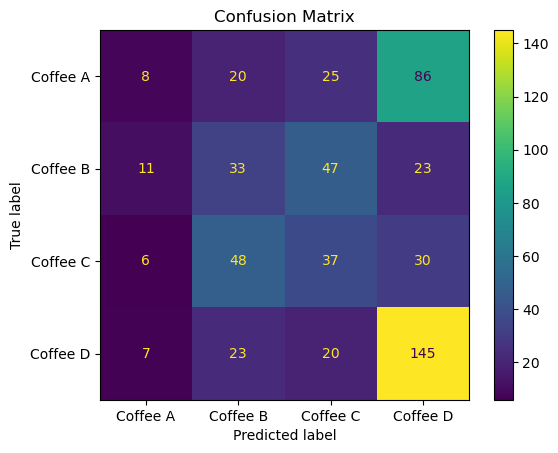

In [125]:
# Evaluate the model

class_eval(y_test, y_pred, labels=log_grid_model.classes_)

In [126]:
# Save the accuracy scores in a running dictionary for a quick final comparision 

model_accur = {}

model_accur['LogClass'] = accuracy_score(y_test, y_pred)

In [127]:
model_accur

{'LogClass': 0.39191564147627417}

### Support Vector Classification

In [128]:
from sklearn.svm import SVC

In [129]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC())
])

In [130]:
param_grid = {'classifier__C': np.logspace(-3, 2, 6),
              'classifier__gamma':['scale','auto']}

In [131]:
svc_grid_model = GridSearchCV(pipe, param_grid,cv=5,scoring='accuracy')

In [132]:
svc_grid_model.fit(X_train, y_train)

,estimator,"Pipeline(step...ier', SVC())])"
,param_grid,"{'classifier__C': array([1.e-03...e+01, 1.e+02]), 'classifier__gamma': ['scale', 'auto']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [133]:
svc_grid_model.best_params_

{'classifier__C': np.float64(1.0), 'classifier__gamma': 'scale'}

In [134]:
y_pred = svc_grid_model.predict(X_test)

              precision    recall  f1-score   support

    Coffee A       0.26      0.04      0.07       139
    Coffee B       0.30      0.33      0.32       114
    Coffee C       0.32      0.36      0.34       121
    Coffee D       0.51      0.74      0.61       195

    accuracy                           0.41       569
   macro avg       0.35      0.37      0.33       569
weighted avg       0.37      0.41      0.36       569



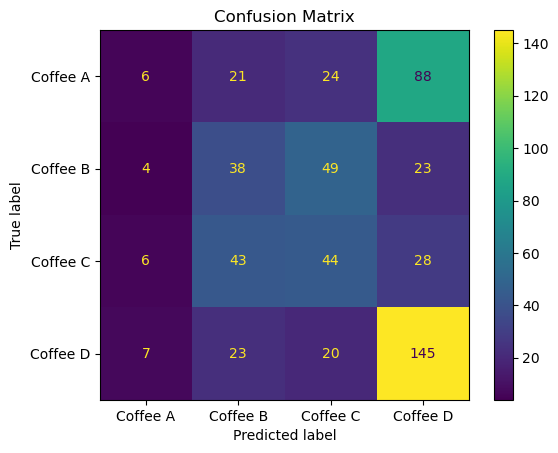

In [135]:
class_eval(y_test, y_pred, labels=svc_grid_model.classes_)

In [136]:
model_accur['SVC'] = accuracy_score(y_test, y_pred)

In [137]:
model_accur

{'LogClass': 0.39191564147627417, 'SVC': 0.4094903339191564}

### Random Forest Classifier

In [138]:
from sklearn.ensemble import RandomForestClassifier

In [139]:
pipe = Pipeline([('classifier', RandomForestClassifier(random_state=90))])

In [140]:
param_grid = {'classifier__n_estimators': [10,50,100,200],
              'classifier__max_features':['sqrt','log2']}

In [141]:
rf_grid_model = GridSearchCV(pipe, param_grid,cv=5,scoring='accuracy')

In [142]:
rf_grid_model.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=90))])
,param_grid,"{'classifier__max_features': ['sqrt', 'log2'], 'classifier__n_estimators': [10, 50, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [143]:
rf_grid_model.best_params_

{'classifier__max_features': 'log2', 'classifier__n_estimators': 100}

In [144]:
y_pred = rf_grid_model.predict(X_test)

              precision    recall  f1-score   support

    Coffee A       0.42      0.08      0.13       139
    Coffee B       0.29      0.35      0.32       114
    Coffee C       0.39      0.33      0.36       121
    Coffee D       0.50      0.77      0.61       195

    accuracy                           0.43       569
   macro avg       0.40      0.38      0.35       569
weighted avg       0.42      0.43      0.38       569



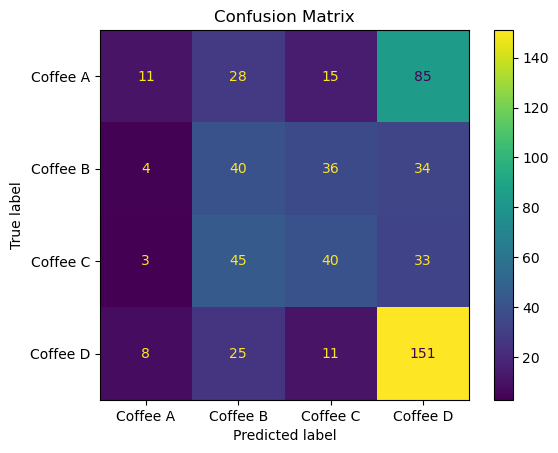

In [145]:
class_eval(y_test, y_pred, labels=rf_grid_model.classes_)

In [146]:
model_accur['RandomForest'] = accuracy_score(y_test, y_pred)

In [147]:
model_accur

{'LogClass': 0.39191564147627417,
 'SVC': 0.4094903339191564,
 'RandomForest': 0.4253075571177504}

Ultimately, the classification effort was very effective. Accuracy across all three model types hovered around 50%, performing no better than random chance. 

We may still glean come information from alternative methods like clustering to help us build customer profiles.

# 5) KModes Clustering

In [148]:
X = pd.get_dummies(df)

In [149]:
from kmodes.kmodes import KModes

In [150]:
# Iterate through different numbers of clusters and aggregate sum of squared distances

cost = []
K = range(1,20)
for k in list(K):
    kmode = KModes(n_clusters=k, init = "random", n_init = 5, verbose=0, random_state=90)
    kmode.fit_predict(X)
    cost.append(kmode.cost_)
    

# State 9

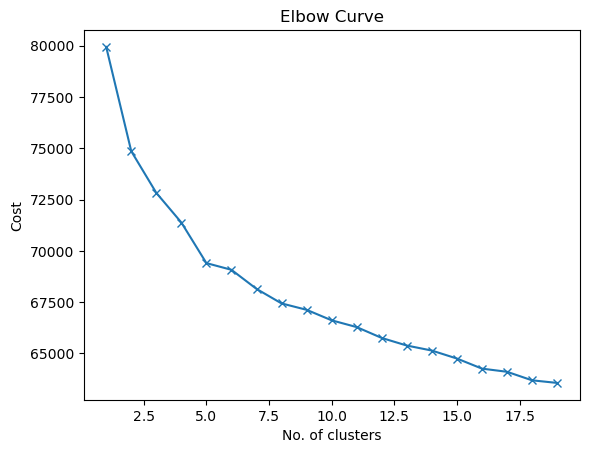

In [151]:
# Plot the square of summed distances

plt.plot(K, cost, 'x-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Curve')
plt.show()

Using the elbow method, its likely that three to four clusters could yield a good result.

We'll implement four clusters and see how interpretable the results end up being.

In [152]:
model = KModes(n_clusters=3, init = "random", n_init = 5, verbose=0, random_state=90)

In [153]:
cluster_labels = model.fit_predict(X)

In [154]:
X['Cluster'] = cluster_labels

X['Cluster'].unique()

array([1, 0, 2], dtype=uint16)

Let's shrink down our feature set using Principal Components Analysis to get a sense of whether four clusters is reasonable.

In [155]:
from sklearn.decomposition import PCA

In [156]:
pca = PCA(n_components=2)

In [157]:
pca_2 = pca.fit_transform(X)

reduced_X=pd.DataFrame(data=pca_2,columns=['PCA1','PCA2'])

Text(0, 0.5, 'Second Principal Component')

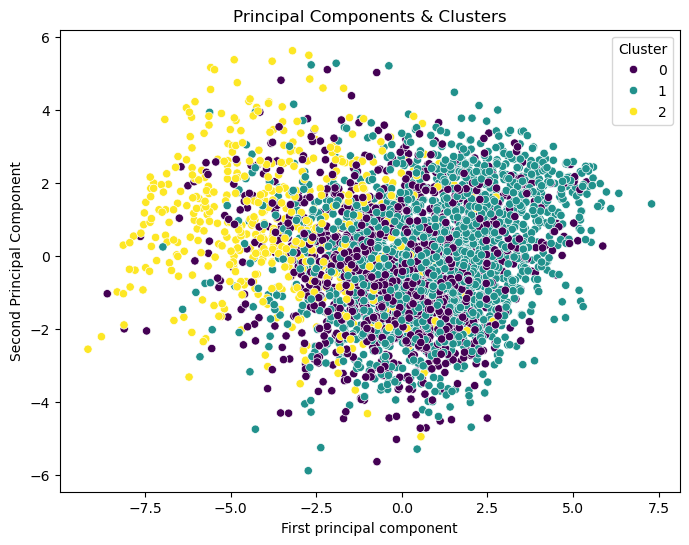

In [158]:
# Display clusters across the principal components scatterplot

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_2[:,0], y=pca_2[:,1], hue=X['Cluster'], palette='viridis')
plt.title('Principal Components & Clusters')
plt.xlabel('First principal component')
plt.ylabel('Second Principal Component')

PCA shows that the clustering results are reasonably separated, if a bit overlapping with group 2.

Ultimately, a look at the data with good background in coffee will help us determine whether these clusters will yield informative customer profiles.

In [159]:
# Pull together the mode values for each cluster

df['Cluster'] = cluster_labels

clust_sum_0 = df[df['Cluster']==0].mode()[:1]
clust_sum_1 = df[df['Cluster']==1].mode()[:1]
clust_sum_2 = df[df['Cluster']==2].mode()[:1]
clust_sum_3 = df[df['Cluster']==3].mode()[:1]

In [160]:
# Define a new dataframe with this info

clust_df = pd.concat([clust_sum_0, clust_sum_1, clust_sum_2, clust_sum_3], axis=0).reset_index(drop=True)

In [161]:
# Show only the columns where the values differ from each other to help pull out the unique attributes.

clust_df.loc[:, clust_df.nunique() > 1]

,Cups per Day,Preferred Coffee Drink,Preferred Coffee Description,Preferred Coffee Strength,Preferred Roast,Reported Coffee Expertise,Favorite Coffee Overall,Monthly Coffee Spend,Coffee Sourcing Knowledge,Max Coffee Cup Purchase,...,Gender,Tasting Score,Coffee Drinking Reason_I need the caffeine,Coffee Drinking Reason_I need the ritual,Work Setup_I primarily work from home,Dairy Type_None,"Coffee Additions_Milk, dairy alternative, or coffee creamer",Coffee Additions_No - just black,Home Brew Method_Pour over,Cluster
0,1.0,Latte,Chocolatey,3.0,Medium,6.0,Coffee D,1.0,Yes,3.0,...,Male,7.0,False,False,True,False,True,False,True,0
1,2.0,Pourover,Fruity,3.0,Light,7.0,Coffee D,1.0,Yes,4.0,...,Male,7.0,True,True,False,True,False,True,True,1
2,1.0,Latte,Chocolatey,2.0,Medium,1.0,Coffee B,0.0,No,3.0,...,Female,6.0,True,False,False,False,True,False,False,2


Examining the modes across clusters, there's a few distinct attributes we can pick out that help us define potential coffee drinker and/or customer profiles.

##### 1) Specialty Pourover Purist: 
- Favorite: Coffee D - Light Roast
- Prefers pourovers and takes their coffees black
- Seeks fruity, light roasted coffees - akin to Coffee D
- Highly confident in abilities and tends to have a more developed palette
- A high spender, chasing the best equipment and pricy, high quality cafe drinks
- Aiming for a great experience from their coffee, focused on the ritual of coffee brewing
- Predominantly male

##### 2) Flexible Espresso Afficinado 
- Favorite: Coffee D - Light Roast
- Lattes are their drink of choice
- Signals a preference for medium roasted coffees with a chocolately note
- Yet enjoys Coffee D, signaling they could be a consumer that's open to purchasing a variety of coffees
- Spend heavily on coffee equipment, likely on an expensive home espresso setup
- Boasts a high self-reported expertise level and tasting score
- Predominantly male

##### 3) Casual Coffee Enjoyer
- Favorite: Coffee B - Medium Roast
- Prefers lattes, but aims for a sweet note, implying the addition of sweeteners to their drink
- Leans less knowledgeable in coffee with a lower self-reported expertise and middle-of-road tasting score
- Drinks fewer cups overall, mainly for the caffeine bump
- Predominantly Female



# Closing Thoughts

Before closing out, it's important to reiterate the caveats mentioned at the start of the analysis. Hoffmann's survey was filled out by very knowledgeable coffee drinkers, as proven by the self-reported scoring and tasting score distributions. This data would only be well suited for coffee shops or roasters looking to reach enthusiast customers.

With that scenario in mind, a specialty coffee shop is poised to do well if they supply more lightly roasted, fermented coffees based on the survey results.

    - They can attract high-spend, young male customers with a focus on high-quality, experience-first offerings like pourovers and distinct lattes.

    - Meanwhile, the shop can ensure its still reaching women by having a smaller supply of darker roasted, espresso-focused coffees well-suited for whipping up sweeter milk-based drinks.
